import significa "traer una herramienta externa al programa"

numpy (abreviado como np) es una librería (un conjunto de herramientas) que permite trabajar con matemática avanzada, especialmente arreglos y matrices.

In [34]:
import numpy as np

In [35]:
import matplotlib.pyplot as plt

In [36]:
from sklearn.neighbors import LocalOutlierFactor

"sklearn” (scikit-learn) es una librería de inteligencia artificial y machine learning.
Dentro de ella está el módulo “neighbors”.

Dentro de “neighbors” está la clase LocalOutlierFactor, que es un algoritmo que sirve para detectar puntos raros, también llamados outliers.

¿Qué es un outlier?
Un dato que “se sale del grupo”, que está lejos de los demás. Por ejemplo, si todos pesan 70–80 kilos y alguien pesa 200, es un outlier.

In [37]:
np.random.seed(42)

Configura el generador de números aleatorios para que siempre produzca los mismos valores.
Porque si tu programa genera puntos al azar, no podrás repetir exactamente los mismos resultados cada vez que lo ejecutes.
Con seed(42) aseguramos:
siempre salen los mismos datos aleatorios

el ejemplo es reproducible

el gráfico no cambia cada vez

In [38]:
#Generamos los datos de entrenamiento 

In [39]:
X_inliers = 0.3 * np.random.randn(100, 2)

np.random.randn(100,2) Es un generador de números aleatorios que siguen una distribución normal (también llamada campana de Gauss).
genera 100 filas
cada una de las filas con 2 números
los números siguen una distribución normal con media 0 y desviación estándar 1
¿Por qué hacemos 0.3 * ...? Porque queremos que los puntos estén más juntos y centrados.
Multiplicar los valores aleatorios por 0.3:
reduce su tamaño

hace que el grupo de puntos sea más compacto

evita que se dispersen demasiado en el gráfico
Antes una fila: [-1.2 0.7] Después de multiplicar x 0.3: [-0.36 0.21]. Mucho más cerca del origen.

¿Qué significa X_inliers = ...? Estamos guardando los resultados en una variable llamada X_inliers.
El nombre viene de:
inlier → punto normal, punto dentro del grupo

lo contrario de outlier, que es un punto raro o externo
X_inliers es un grupo de 100 puntos normales, cada uno con 2 coordenadas (x, y).
Estos serán los datos “buenos” o “normales” del dataset.

In [40]:
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

Qué es X_inliers + 2?
A cada punto del arreglo, súmale 2 a las dos coordenadas:
Si un punto era: [-0.36, 0.21]. Entonces [-0.36 + 2, 0.21 + 2] = [1.64, 2.21]
PREGUNTA AL CURSO: ¿Qué es X_inliers - 2?
RESPUESTA: ¿Qué es X_inliers - 2? [-0.36, 0.21] → [-2.36, -1.79]
¿Qué hace np.r_[ ... , ... ]?
Es una función que une dos conjuntos de datos verticalmente.
Así: [ grupo desplazado +2 ] [ grupo desplazado -2 ] Resultado: una sola matriz con 200 filas.
¿Por qué hacemos esto?
Generamos dos grupos de puntos “buenos”:
uno centrado alrededor de (2,2)
otro centrado alrededor de (-2,-2)
Estos dos grupos representarán datos normales.

In [41]:
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

¿Qué es np.random.uniform()?
Es un generador de números aleatorios que elige valores entre dos límites:
low=-4 significa el valor mínimo posible es −4
high=4 significa el valor máximo posible es 4
Es como decir:
“Elige números entre −4 y 4”.
¿Qué significa size=(20, 2)?
Vamos a generar 20 puntos, donde cada punto tiene 2 coordenadas (x, y)
Entonces crea una matriz así:
[ [valor, valor], [valor, valor], ... 20 veces ]
¿Por qué estos son outliers?
Porque estos puntos pueden caer en cualquier parte del cuadrado: x entre −4 y 4 y entre −4 y 4
Esto incluye puntos:
Lejos de los grupos normales

Totalmente dispersos

Con ubicaciones aleatorias
Son perfectos para representar “valores raros”.

In [42]:
X = np.r_[X_inliers, X_outliers]

agrupa los valores inliers y los valores outrliers

In [43]:
n_outliers = len(X_outliers)

In [44]:
ground_truth = np.ones(len(X), dtype=int)

len(X) → cuenta todos los puntos (inliers + outliers).
200 inliers
20 outliers
total = 220

np.ones(...) → crea un arreglo lleno de unos. [1, 1, 1, 1, 1, 1, ...]
dtype=int → asegura que sean números enteros.
POR QUÉ LO HACEMOS?
Estamos creando un arreglo que dice:
1 = punto normal (inlier)
−1 = punto raro (outlier)
Por ahora marcamos todos como normales, pero en la siguiente línea corregiremos eso.

In [45]:
ground_truth[-n_outliers:] = -1

ground_truth es una lista de 1s: [1, 1, 1, 1, ... 1]
-n_outliers: significa: “las últimas n_outliers posiciones”, o sea, los últimos 20 elementos
Si hay 220 datos: tomamos los elementos 200 al 219 y les ponemos −1

In [46]:
#Aquí vamos a entrenar el modelo para detectar puntos raros
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

In [47]:
#Usaremos fit_predict para obtener las etiquetas (normal o outlier).
#LOF no permite predecir sobre datos nuevos cuando se usa como detector de outliers.
#LOF estudia densidades locales del conjunto completo
#Si le damos un nuevo punto, no sabe dónde encajarlo
#Para eso existe un modo especial llamado novelty=True (pero aquí no lo usaremos)
y_pred = clf.fit_predict(X)

In [48]:
n_errors = (y_pred != ground_truth).sum()

Esta línea compara las prediciones generados en en código anterior etiquetadas como (normal o outlier) en la columna "y_pred", con la verdad fundamental "ground_truth" (los valores reales o etiquetados) y cuenta cuántos valores no coinciden (es decir, los errores de predicción).

y_pred != ground_truth, revisa uno por uno si el valor predicho es diferente al valor real. Si son distintos (los que se enbcuentran en el orden del 4,-4), pone True (hay un error).Si son iguales (lois que ser encuentran en el orden del 2,-2), pone False (la predicción fue correcta).

.sum() cuenta cuántos valores son True, es decir, cuántos errores de predicción hay.

In [49]:
X_scores = clf.negative_outlier_factor_

Con este código se obtiene el Local Outlier Factor (LOF) para cada punto de datos, que indica qué tan fuera de rango es cada punto en el conjunto de datos. 
 
negative_outlier_factor_ es un clasificador de LOF, devuelve la puntuación LOF para cada punto. Los valores negativos de esta puntuación indican que el punto es un outlier.

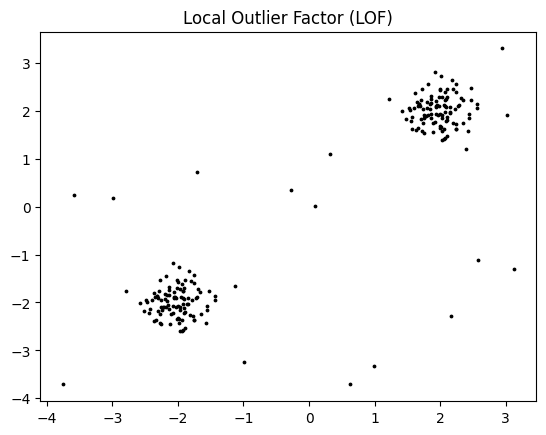

In [50]:
plt.title("Local Outlier Factor (LOF)")
sc_points = plt.scatter(X[:, 0], X[:, 1], color='k', s=3., label='Data poins')

plt.title("Local Outlier Factor (LOF)"), establece el título de la gráfica. 

sc_points = plt.scatter(X[:, 0], X[:, 1], color='k', s=3., label='Data points')
Crea una gráfica de dispersión (scatter plot) de los puntos de datos en el espacio bidimensional 
(X[:, 0] y X[:, 1]  corresponden a las dos primeras características de X).
color='k'           indica que los puntos serán de color negro.
s=3.                establece el tamaño de los puntos en el gráfico.
label=              'Data points' es la etiqueta para estos puntos en la leyenda del gráfico.

En este código fue enviada al final la línea "sc_points", la cual la elimine ya que¿ es redundante, ya  se está mostrando el gráfico de dispersión en la línea anterior.

In [51]:
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

Esta línea de cofigo se calcula el "radio" para los círculos que representan los puntos atípicos.
El radio se obtiene de la división entre:
    (X_scores.max() - X_scores) que es la diferencia entre la puntuación máxima de LOF y la puntuación de cada punto graficado.
    (X_scores.max() - X_scores.min()) con esta diferencia  se obtiene el ragno de las puntuaciones del LOF para estandariza o normalizar los tamaños de los radios. Los tamaños se encontrán en el rango del (o y 1) y de estas mnanera se puede visualizar de mejor manera los outliers sin que la circuenferenica graficada sea distorcionada.
El resultado es un valor entre 0 y 1 que indica qué tan "outliers" o "atípicos" son los puntos.

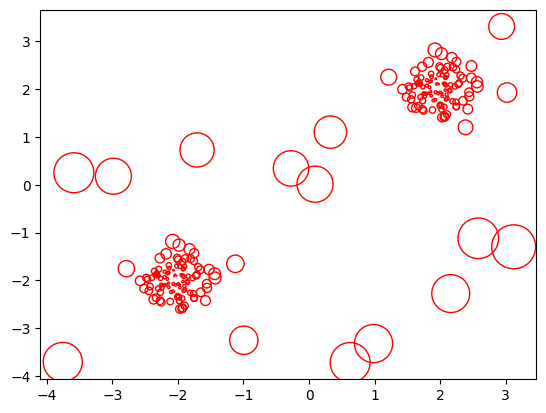

In [52]:
sc_circles = plt.scatter(X[:, 0], X[:, 1], s=1000 * radius, edgecolors='r', 
facecolors='none', label='Outlier scores')

Esta línea  de código dibuja círculos alrededor de los puntos de datos, donde el tamaño de cada círculo está determinado por su puntuación LOF (el valor de radio caluclado en la línea anterior).

s=1000 * radius escala el tamaño de los círculos, multiplicado por 1000 para hacer los círculos suficientemente grandes.

edgecolors='r' hace que los bordes de los círculos sean rojos.

facecolors='none' hace que los círculos no tengan color de relleno, solo borde.

label='Outlier scores' establece la etiqueta para los círculos en la leyenda.

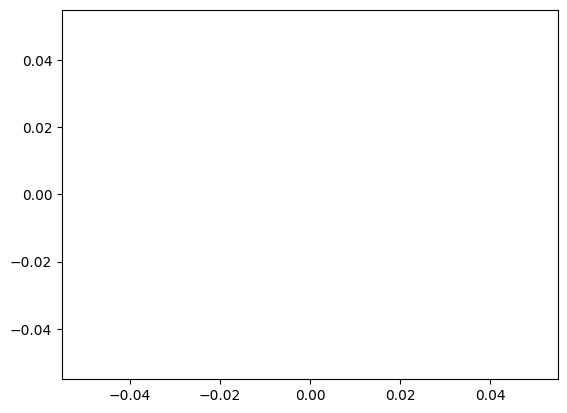

In [53]:
plt.autoscale()

"plt.autoscale()" ajusta automáticamente los límites del gráfico para asegurarse de que todos los puntos y círculos estén visibles. Es útil para que los círculos de los outliers no se corten o salgan del área visible.

Text(0.5, 0, 'prediction errors: 8')

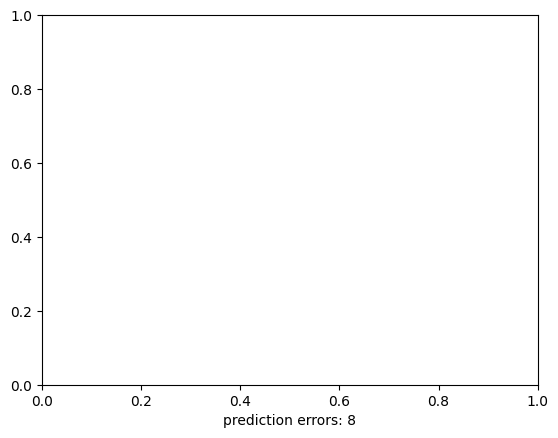

In [54]:
plt.xlabel(f"prediction errors: {n_errors}")

plt.xlabel  permite plotear una etiqueta y al colocar "x" especificas el eje, en este caso al eje x se etiqueta con el número de errores de predicción (n_errors). Se utiliza f-string para insertar el valor de n_errors directamente en el texto.

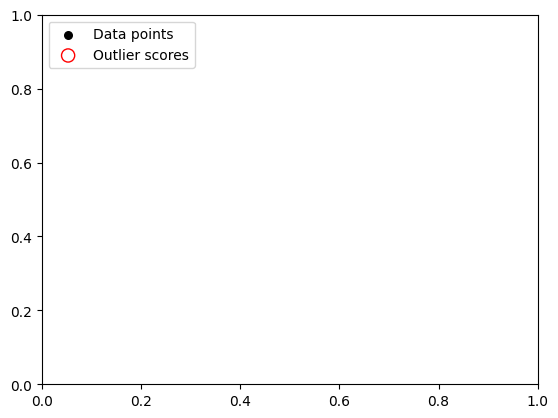

In [55]:
leg = plt.legend(handles=[sc_points, sc_circles],
                 labels=['Data points', 'Outlier scores'],
                 loc='upper left')

leg.legend_handles[0].set_sizes([30])
leg.legend_handles[1].set_sizes([90])

Con esta línea se crea una leyenda en la gráfica para etiquetar los diferentes elementos:

sc_points representa los puntos de datos.

sc_circles representa los círculos que indican los outliers.

loc='upper left' coloca la leyenda en la esquina superior izquierda del gráfico.

leg.legend_handles[0].set_sizes([30])
Ajusta el tamaño de los puntos de datos en la leyenda. Aquí, los puntos en la leyenda tendrán un tamaño de 30.

leg.legend_handles[1].set_sizes([90])
Ajusta el tamaño de los círculos de los outliers en la leyenda. Aquí, los círculos en la leyenda tendrán un tamaño de 90.

In [61]:
plt.show()